In [71]:
import numpy as np
import re
from collections import Counter


In [72]:
from safetensors.numpy import load_file


weights = load_file("model.safetensors")


W = weights["W"]
W_prime = weights["W_prime"]

print(f"Loaded matrix W with shape: {W.shape}")
print(f"Loaded matrix W' with shape: {W_prime.shape}")

Učitana matrica W oblika: (18497, 100)
Učitana matrica W' oblika: (100, 18497)


In [73]:

def load_text(filepath) -> str:
    """
    :param filepath: PATH to the text file
    Load text from filepath
    """
    with open(filepath, 'r') as f:
        return f.read()


def tokenize(text) -> list[str]:
    """
    Clean and tokenize text:
    - lowercase everything
    - remove everything except letters and spaces
    - split into words
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

In [74]:
def build_vocab(words, min_count=50):
    """
    :param words: list of words
    :param min_count: minimum number of times a word appears
    :return: word2idx, idx2word, filtered words, word_counts
    """
    word_counts = Counter(words)


    word_counts = {
        word: count
        for word, count in word_counts.items()
        if count >= min_count
    }

    word2idx = {word: idx for idx, word in enumerate(word_counts.keys())}
    idx2word = {idx: word for word, idx in word2idx.items()}

    # keep only words that are in vocabulary
    words = [word for word in words if word in word2idx]

    return word2idx, idx2word, words, word_counts

In [75]:
text  = load_text('text8')
words = tokenize(text)
word2idx, idx2word, words, word_counts = build_vocab(words, 50)

In [112]:
def most_similar(word, word2idx, idx2word, W, top_n=5) -> None:
    """
    :param word: target word
    :param word2idx: dict -> word:index
    :param idx2word: dict -> index:word
    :param W: input weight matrix (V, N)
    :param top_n: number of nearest neighbors
    """
    if word not in word2idx:
        print(f"Word '{word}' not found in vocabulary!")
        return

    idx   = word2idx[word]
    h     = W[idx]
    norms = np.linalg.norm(W, axis=1)
    sims  = W @ h / (norms * np.linalg.norm(h) + 1e-10)

    top_idxs = np.argsort(sims)[::-1][1:top_n + 1]

    print(f"\nMost similar words to '{word}':")
    for i in top_idxs:
        print(f"  {idx2word[i]:<15} similarity: {sims[i]:.4f}")
def most_similar_vec(target_vec, word2idx, idx2word, W, top_n, word_a, word_b, word_c):

    norms = np.linalg.norm(W, axis=1)
    sims     = W @ target_vec / (norms * np.linalg.norm(target_vec) + 1e-10)

    # exclude input words from results
    exclude  = {word2idx[w] for w in [word_a, word_b, word_c]}
    top_idxs = [i for i in np.argsort(sims)[::-1]
                    if i not in exclude][:top_n]

    print(f"\nMost similar words to:")
    for i in top_idxs:
        print(f"  {idx2word[i]:<15} similarity: {sims[i]:.4f}")

In [113]:
most_similar("computer", word2idx, idx2word, W, top_n=5)


Most similar words to 'computer':
  video           similarity: 0.7166
  software        similarity: 0.6804
  analysis        similarity: 0.6616
  game            similarity: 0.6557
  designers       similarity: 0.6514


In [114]:
exp = W[word2idx["paris"]] - W[word2idx["france"]] + W[word2idx["germany"]]
most_similar_vec(exp, word2idx, idx2word, W, 1, "paris", "france", "germany")


Most similar words to:
  berlin          similarity: 0.7146


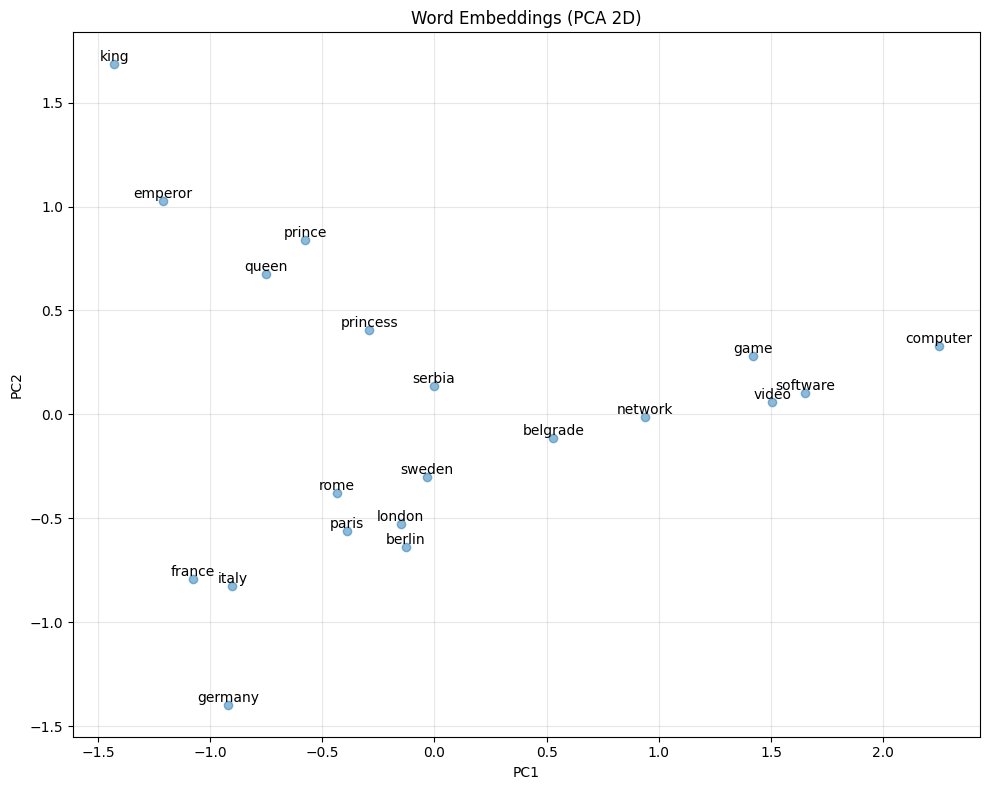

In [115]:
import matplotlib.pyplot as plt

def pca(X, n_components=2):
    X = X - X.mean(axis=0)
    cov = np.cov(X.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx  = np.argsort(eigvals)[::-1][:n_components]
    return X @ eigvecs[:, idx]


def plot_words(words_to_plot, W, word2idx):

    words_to_plot = [w for w in words_to_plot if w in word2idx]
    vecs          = np.array([W[word2idx[w]] for w in words_to_plot])

    vecs_2d = pca(vecs)

    plt.figure(figsize=(10, 8))
    plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], alpha=0.5)

    for i, word in enumerate(words_to_plot):
        plt.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]),
                     fontsize=10, ha='center', va='bottom')

    plt.title('Word Embeddings (PCA 2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


words_to_plot = [

    'king', 'queen', 'prince', 'princess', 'emperor',

    'france', 'germany', 'sweden', 'italy', 'serbia',

    'paris', 'berlin', 'london', 'rome', 'belgrade',

    'computer', 'software', 'network', 'video', 'game',
]

plot_words(words_to_plot, W, word2idx)